# Masking into MERRA-2 Datasets

A little notebook to showcase how I might start using my catalog to mask into MERRA-2

In [1]:
%pip install --quiet "h5coro>=0.0.7"

Note: you may need to restart the kernel to use updated packages.


In [10]:
import pandas as pd
import xarray as xr
import numpy as np
import os
from pathlib import Path
import seaborn as sns
import xarray as xr
from tqdm import tqdm

import h5py
import boto3
from h5coro import h5coro, s3driver
import s3fs
import earthaccess
from IPython.display import display, Markdown
from ipywidgets import IntProgress

home_dir = str(Path(os.getcwd()).parents[0])

## Setting Up MERRA-2 Streaming

In [3]:
if (boto3.client('s3').meta.region_name == 'us-west-2'):
    display(Markdown('### us-west-2 Region Check: &#x2705;'))
else:
    display(Markdown('### us-west-2 Region Check: &#10060;'))
    raise ValueError('Your notebook is not running inside the AWS us-west-2 region, and will not be able to directly access NASA Earthdata S3 buckets')

### us-west-2 Region Check: &#x2705;

## Loading Up the Catalog

In [3]:
# load up all of the dataframes by year, and then concatenate into one big one
df_path = home_dir + '/data/ar_database/dataframes/'
fnames = os.listdir(df_path)
df_list = []

for fname in fnames:
    df_list.append(pd.read_pickle(df_path + fname))
    
dataframe = pd.concat(df_list)

ModuleNotFoundError: No module named 'numpy._core.numeric'

## Storm Characteristics

Adding storm characteristics to the database using MERRA-2 data.

### Areas and Durations

In [4]:
# load up relevant MERRA-2 datasets
grid_areas = xr.open_dataset(home_dir + '/data/area/MERRA2_gridarea.nc')
grid_areas = grid_areas.sel(lat=slice(-86, -39)).cell_area

In [5]:
def compute_max_area(ar_da):
    da = ar_da.rename({'lats':'lat', 'lons':'lon'})
    grid_area_storm = grid_areas.sel(lat=da.lat, lon=da.lon)
    max_area = float(da.dot(grid_area_storm).max().values/(1000**2))
    return max_area

def compute_mean_area(ar_da):
    da = ar_da.rename({'lats':'lat', 'lons':'lon'})
    grid_area_storm = grid_areas.sel(lat=da.lat, lon=da.lon)
    mean_area = float(da.dot(grid_area_storm).mean().values/(1000**2))
    return mean_area

def compute_duration(ar_da):
    days = (ar_da.time.max() - ar_da.time.min()).values.astype('timedelta64[h]').astype(int) + np.timedelta64(3, 'h')
    return days

def add_start_date(ar_da):
    start = ar_da.time.min().values
    return start

def add_end_date(ar_da):
    end = ar_da.time.max().values
    return end

In [6]:
dataframe['max_area'] = dataframe['data_array'].apply(compute_max_area)
dataframe['mean_area'] = dataframe['data_array'].apply(compute_mean_area)
dataframe['duration'] = dataframe['data_array'].apply(compute_duration)
dataframe['start_date'] = dataframe['data_array'].apply(add_start_date)
dataframe['end_date'] = dataframe['data_array'].apply(add_end_date)

In [9]:
attr_df = dataframe[['max_area', 'mean_area', 'duration', 'start_date', 'end_date', 'is_landfalling']]

In [10]:
attr_df = attr_df.sort_values(by='start_date')

### Atmospheric Variables

In [14]:
cell_areas = xr.open_dataset('/home/jovyan/extreme_antarctic_ARs/data/area/MERRA2_gridarea.nc')
cell_areas = cell_areas.cell_area
ais_mask = xr.open_dataset('/home/jovyan/extreme_antarctic_ARs/data/antarctic_masks/AIS_Full_basins_Zwally_MERRA2grid_new.nc')
ais_mask = ais_mask > 0

In [15]:
def compute_cumulative(storm_da, var_da, area_da, ais_da=None):
    if ais_da:
        storm_ais_mask = ais_da.sel(lat=storm_da.lat, lon=storm_da.lon).Zwallybasins
        storm_da_subset = storm_da.where(storm_ais_mask, 0)
    else:
        storm_da_subset = storm_da.copy()

    var_da_subset = var_da.sel(lat=storm_da_subset.lat, lon=storm_da_subset.lon)

    storm_cell_areas = area_da.sel(lat=storm_da.lat, lon=storm_da.lon)
    avg_storm_val = storm_cell_areas.dot(storm_da_subset*var_da_subset).mean().values

    return avg_storm_val

def compute_max_intensity(storm_da, var_da, ais_da=None):
    if ais_da:
        storm_ais_mask = ais_da.sel(lat=storm_da.lat, lon=storm_da.lon).Zwallybasins
        storm_da_subset = storm_da.where(storm_ais_mask, 0)
    else:
        storm_da_subset = storm_da.copy()
        
    var_da_subset = var_da.sel(lat=storm_da_subset.lat, lon=storm_da_subset.lon)
    max_intensity_val = (storm_da_subset*var_da_subset).max().values

    return max_intensity_val

def compute_average(storm_da, var_da, area_da, ais_da=None):
    if ais_da:
        storm_ais_mask = ais_da.sel(lat=storm_da.lat, lon=storm_da.lon).Zwallybasins
        storm_da_subset = storm_da.where(storm_ais_mask, 0)
    else:
        storm_da_subset = storm_da.copy()

    var_da_subset = var_da.sel(lat=storm_da_subset.lat, lon=storm_da_subset.lon)

    storm_cell_areas = area_da.sel(lat=storm_da.lat, lon=storm_da.lon)
    tot_area = storm_da_subset.dot(storm_cell_areas)
    avg_storm_val = (storm_cell_areas.dot(storm_da_subset*var_da_subset)/tot_area).mean().values

    return avg_storm_val

#### 2m-Temperature, 10m Poleward Wind, Total Precipitable Vapor

In [21]:
auth = earthaccess.login()
data_doi = '10.5067/3Z173KIE2TPD'
# Get S3 credentials for accessing the gesdisc data
s3_creds = earthaccess.get_s3_credentials(results=results)

# Extract the credentials
#aws_access_key_id = s3_creds['accessKeyId']
#aws_secret_access_key = s3_creds['secretAccessKey']
#aws_session_token = s3_creds['sessionToken']

# Initialize S3FileSystem with the obtained credentials
#fs = s3fs.S3FileSystem(key=aws_access_key_id,
#                       secret=aws_secret_access_key,
#                       token=aws_session_token)

import time

In [32]:
%%timeit
data_doi = '10.5067/3Z173KIE2TPD'
concept_id = 'C1276812820-GES_DISC'
results = earthaccess.search_data(doi=data_doi, 
                                  temporal=('2020-2-24', 
                                            '2020-2-27'));
paths = earthaccess.open(results)

QUEUEING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/4 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

...

COLLECTING RESULTS | :   0%|          | 0/4 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/4 [00:00<?, ?it/s]

1.06 s ± 121 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [33]:
%%time
# Initialize the H5Coro object with the S3 driver and credentials
h5obj = h5coro.H5Coro(paths[0].details['name'], h5coro.s3driver.S3Driver, 
                      credentials=s3_creds, errorChecking=True, verbose=False, multiProcess=False)

# Define the variables you want to read
variables = ['SLP', 'T2M', 'V10M']
# Read the data using h5coro
data = h5obj.readDatasets(variables, block=True, enableAttributes=False)

CPU times: user 12.7 s, sys: 189 ms, total: 12.9 s
Wall time: 12.9 s


In [34]:
%%time

obs_ds = xr.open_mfdataset(paths);

CPU times: user 2.56 s, sys: 196 ms, total: 2.76 s
Wall time: 7.79 s


In [35]:
obs_ds

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 96, lat: 361, lon: 576)
Coordinates:
  * lon      (lon) float64 5kB -180.0 -179.4 -178.8 -178.1 ... 178.1 178.8 179.4
  * lat      (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5 90.0
  * time     (time) datetime64[ns] 768B 2020-02-24 ... 2020-02-27T23:00:00
Data variables: (12/24)
    DISPH    (time, lat, lon) float32 80MB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    PS       (time, lat, lon) float32 80MB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    QV10M    (time, lat, lon) float32 80MB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    QV2M     (time, lat, lon) float32 80MB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    SLP      (time, lat, lon) float32 80MB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    T10M     (time, lat, lon) float32 80MB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    ...       ...
    U10M     (time, lat, lon) float32 80MB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    U2M      (time, lat, lon) float32 80MB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    U50M     (time, lat, lon) float32 80MB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    V10M     (time, lat, lon) float32 80MB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    V2M      (time, lat, lon) float32 80MB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    V50M     (time, lat, lon) float32 80MB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
Attributes: (12/30)
    History:                           Original file generated: Thu Mar  5 21...
    Comment:                           GMAO filename: d5124_m2_jan10.inst1_2d...
    Filename:                          MERRA2_400.inst1_2d_asm_Nx.20200224.nc4
    Conventions:                       CF-1
    Institution:                       NASA Global Modeling and Assimilation ...
    References:                        http://gmao.gsfc.nasa.gov
    ...                                ...
    Contact:                           http://gmao.gsfc.nasa.gov
    identifier_product_doi:            10.5067/3Z173KIE2TPD
    RangeBeginningDate:                2020-02-24
    RangeBeginningTime:                00:00:00.000000
    RangeEndingDate:                   2020-02-24
    RangeEndingTime:                   23:00:00.000000

In [ ]:
# Convert to dataArray
xr_cover_coro = xr.DataArray(data=data['BEAM0001/cover'],
                        coords={'lat':(['x'],data['BEAM0001/geolocation/lat_lowestmode']),
                                'lon':(['x'],data['BEAM0001/geolocation/lon_lowestmode'])},
                        dims = ['x'])

In [4]:
import time
login_time = time.time()
auth = earthaccess.login()
login_time = time.time() - login_time

data_doi = '10.5067/3Z173KIE2TPD'
vars = ['T2M']

dataframe_landfalling = dataframe[dataframe.is_landfalling]
t2m_vals = [None]*len(dataframe_landfalling)

i = 10

storm_da = dataframe.iloc[i].data_array
storm_da = storm_da.rename({'lats':'lat', 'lons':'lon'})

max_min_time = time.time()
first = np.min(storm_da.time.dt.date.to_numpy())
last = np.max(storm_da.time.dt.date.to_numpy())
max_min_time = time.time() - max_min_time
# stream the data only between those two dates

search_time = time.time()
results = earthaccess.search_data(doi=data_doi, 
                                  temporal=(f'{first.year}-{first.month}-{first.day}', 
                                            f'{last.year}-{last.month}-{last.day}'));
search_time = time.time() - search_time

open_time = time.time()
obs_ds = xr.open_mfdataset(earthaccess.open(results));
open_time = time.time() - open_time
obs_ds = obs_ds.sel(time = obs_ds.time.dt.hour % 3 == 0).sel(lat = slice(-86, -39))
obs_ds = obs_ds[vars]

compute_time = time.time()
compute_average(storm_da, obs_ds.T2M, cell_areas)
compute_time = time.time() - compute_time

QUEUEING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/2 [00:00<?, ?it/s]

NameError: name 'compute_average' is not defined

In [5]:
obs_ds

<xarray.Dataset> Size: 4MB
Dimensions:  (time: 16, lat: 95, lon: 576)
Coordinates:
  * lon      (lon) float64 5kB -180.0 -179.4 -178.8 -178.1 ... 178.1 178.8 179.4
  * lat      (lat) float64 760B -86.0 -85.5 -85.0 -84.5 ... -40.0 -39.5 -39.0
  * time     (time) datetime64[ns] 128B 1993-01-26 ... 1993-01-27T21:00:00
Data variables:
    T2M      (time, lat, lon) float32 4MB dask.array<chunksize=(1, 83, 144), meta=np.ndarray>
Attributes: (12/30)
    History:                           Original file generated: Mon Jun 30 06...
    Comment:                           GMAO filename: d5124_m2_jan91.inst1_2d...
    Filename:                          MERRA2_200.inst1_2d_asm_Nx.19930126.nc4
    Conventions:                       CF-1
    Institution:                       NASA Global Modeling and Assimilation ...
    References:                        http://gmao.gsfc.nasa.gov
    ...                                ...
    Contact:                           http://gmao.gsfc.nasa.gov
    identifier_product_doi:            10.5067/3Z173KIE2TPD
    RangeBeginningDate:                1993-01-26
    RangeBeginningTime:                00:00:00.000000
    RangeEndingDate:                   1993-01-26
    RangeEndingTime:                   23:00:00.000000

In [6]:
results

[Collection: {'ShortName': 'M2I1NXASM', 'Version': '5.12.4'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'WestBoundingCoordinate': -180.0, 'EastBoundingCoordinate': 180.0, 'NorthBoundingCoordinate': 90.0, 'SouthBoundingCoordinate': -90.0}]}}}
 Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '1993-01-26T00:00:00.000Z', 'EndingDateTime': '1993-01-26T23:00:00.000Z'}}
 Size(MB): 198.12285804748535
 Data: ['https://data.gesdisc.earthdata.nasa.gov/data/MERRA2/M2I1NXASM.5.12.4/1993/01/MERRA2_200.inst1_2d_asm_Nx.19930126.nc4'],
 Collection: {'ShortName': 'M2I1NXASM', 'Version': '5.12.4'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'WestBoundingCoordinate': -180.0, 'EastBoundingCoordinate': 180.0, 'NorthBoundingCoordinate': 90.0, 'SouthBoundingCoordinate': -90.0}]}}}
 Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '1993-01-27T00:00:00.000Z', 'EndingDateTime': '1993-01-27T23:00:00.000Z'}}
 Si

In [19]:
login_time

0.9818034172058105

In [21]:
max_min_time

0.0014908313751220703

In [22]:
search_time

8.949399709701538

In [23]:
open_time

6.790618658065796

In [24]:
compute_time

1.2006771564483643

In [145]:
auth = earthaccess.login()

data_doi = '10.5067/3Z173KIE2TPD'
vars = ['T2M']

dataframe_landfalling = dataframe[dataframe.is_landfalling]
t2m_vals = [None]*len(dataframe_landfalling)

for i in tqdm(range(len(dataframe_landfalling))):

    storm_da = dataframe.iloc[i].data_array
    storm_da = storm_da.rename({'lats':'lat', 'lons':'lon'})

    first = np.min(storm_da.time.dt.date.to_numpy())
    last = np.max(storm_da.time.dt.date.to_numpy())
    # stream the data only between those two dates
    results = earthaccess.search_data(doi=data_doi, 
                                  temporal=(f'{first.year}-{first.month}-{first.day}', 
                                            f'{last.year}-{last.month}-{last.day}'));
    obs_ds = xr.open_mfdataset(earthaccess.open(results));
    obs_ds = obs_ds.sel(time = obs_ds.time.dt.hour % 3 == 0).sel(lat = slice(-86, -39))
    obs_ds = obs_ds[vars]

    t2m_vals[i] = compute_average(storm_da, obs_ds.T2M, cell_areas, ais_mask)

  0%|          | 0/2993 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 1/2993 [00:07<5:54:44,  7.11s/it]

...

QUEUEING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/2 [00:00<?, ?it/s]

  1%|          | 37/2993 [03:49<5:06:01,  6.21s/it]


KeyError: "not all values found in index 'lon'"

In [ ]:
first = np.min(storm_da.time.dt.date.to_numpy())
last = np.max(storm_da.time.dt.date.to_numpy())
# stream the data only between those two dates
results = earthaccess.search_data(doi=data_doi, 
                                  temporal=(f'{first.year}-{first.month}-{first.day}', 
                                            f'{last.year}-{last.month}-{last.day}'))
obs_ds = xr.open_mfdataset(earthaccess.open(results))
obs_ds = obs_ds.sel(time = obs_ds.time.dt.hour % 3 == 0).sel(lat = slice(-86, -39))
obs_ds = obs_ds[vars]
obs_ds = obs_ds.sel(lat=storm_da.lat, lon=storm_da.lon)

<Axes: xlabel='start_date', ylabel='mean_area'>

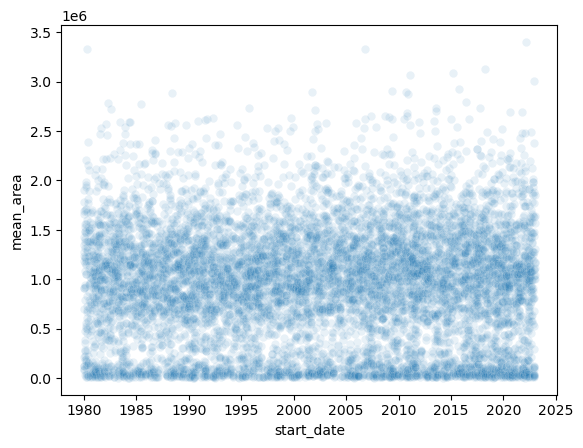

In [11]:
sns.scatterplot(data=attr_df, x='start_date', y='mean_area', alpha=0.1)

<Axes: xlabel='start_date', ylabel='mean_area'>

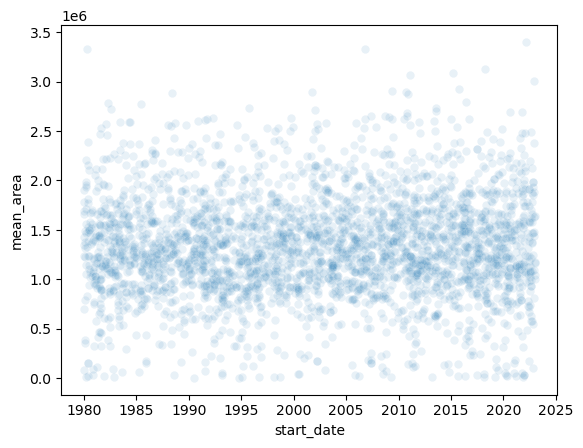

In [12]:
sns.scatterplot(data=attr_df[attr_df['is_landfalling']], x='start_date', y='mean_area', alpha=0.1)

In [1]:
sns.scatterplot(data=attr_df[attr_df['is_landfalling']], x='start_date', y='max_area', alpha=0.1);

NameError: name 'sns' is not defined

In [20]:
attr_df[attr_df.max_area == attr_df.max_area.max()]

,max_area,mean_area,duration,start_date,end_date,is_landfalling
cluster,,,,,,
8161.0,6.299194e+06,3.403829e+06,4 days 18:00:00,2022-03-13 15:00:00,2022-03-18 06:00:00,True


<Axes: xlabel='max_area', ylabel='Count'>

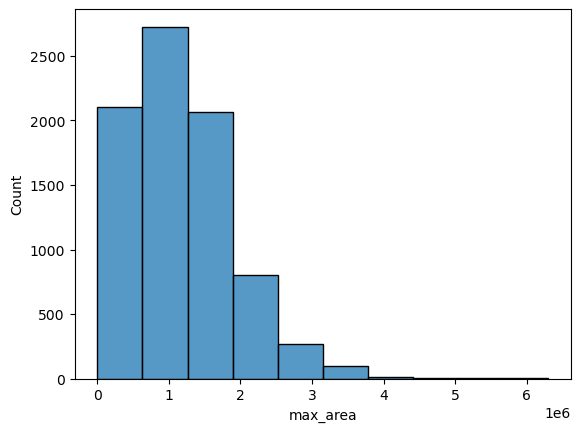

In [21]:
sns.histplot(data=attr_df, x='max_area', bins=10)

<Axes: xlabel='start_date', ylabel='Count'>

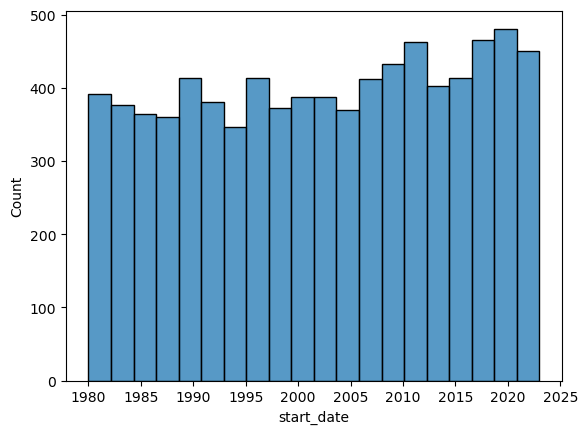

In [22]:
sns.histplot(data=attr_df, x='start_date', bins=20)

<Axes: xlabel='start_date', ylabel='Count'>

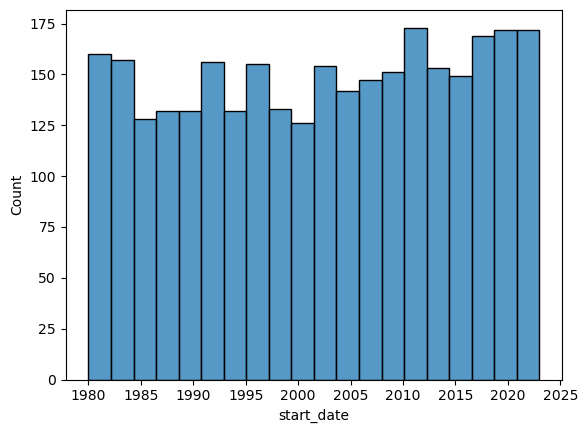

In [23]:
sns.histplot(data=attr_df[attr_df['is_landfalling']], x='start_date', bins=20)

### 10m Winds

In [30]:
start_day = attr_df.start_date.dt.date.iloc[0]
end_day = attr_df.end_date.dt.date.iloc[-1]

In [31]:
days = pd.date_range(start=start_day, end=end_day).strftime('%Y%m%d')

In [32]:
days

Index(['19800102', '19800103', '19800104', '19800105', '19800106', '19800107',
       '19800108', '19800109', '19800110', '19800111',
       ...
       '20221222', '20221223', '20221224', '20221225', '20221226', '20221227',
       '20221228', '20221229', '20221230', '20221231'],
      dtype='object', length=15705)

In [39]:
# load up the 10m wind data

day = days[15000]

In [40]:
day

'20210126'

In [41]:
path

's3://gesdisc-cumulus-prod-protected/MERRA2/M2I1NXASM.5.12.4/2007/05/MERRA2_400.inst1_2d_asm_Nx.20070520.nc4'

In [42]:
path = 's3://gesdisc-cumulus-prod-protected/MERRA2/M2I1NXASM.5.12.4/'+ day[0:4] +'/' + day[4:6] + '/MERRA2_400.inst1_2d_asm_Nx.' + day + '.nc4'
#path = 's3://gesdisc-cumulus-prod-protected/MERRA2/M2I1NXASM.5.12.4/2022/03/MERRA2_400.inst1_2d_asm_Nx.20220315.nc4'
dat = xr.open_dataset(fs.open(path), decode_cf=True,)

In [ ]:

# Files are organized by s3://gesdisc-cumulus-prod-protected/MERRA2/M2T1NXSLV.5.12.4/year/mo/*.nc4
datasets = []

for day in days:
    
    path = 's3://gesdisc-cumulus-prod-protected/MERRA2/M2I1NXASM.5.12.4/'+ day[0:4] +'/' + day[4:6] + '/MERRA2_400.inst1_2d_asm_Nx.' + day + '.nc4'
    dat = xr.open_dataset(fs.open(path), decode_cf=True,)
    antarctic_dat = dat.sel(lat = slice(-90.0, -50.0), lon = slice(-180, 179.4))
    datasets.append(antarctic_dat[['T2M', 'TQV', 'V10M']])